## Transformer Model from Scratch using TensorFlow

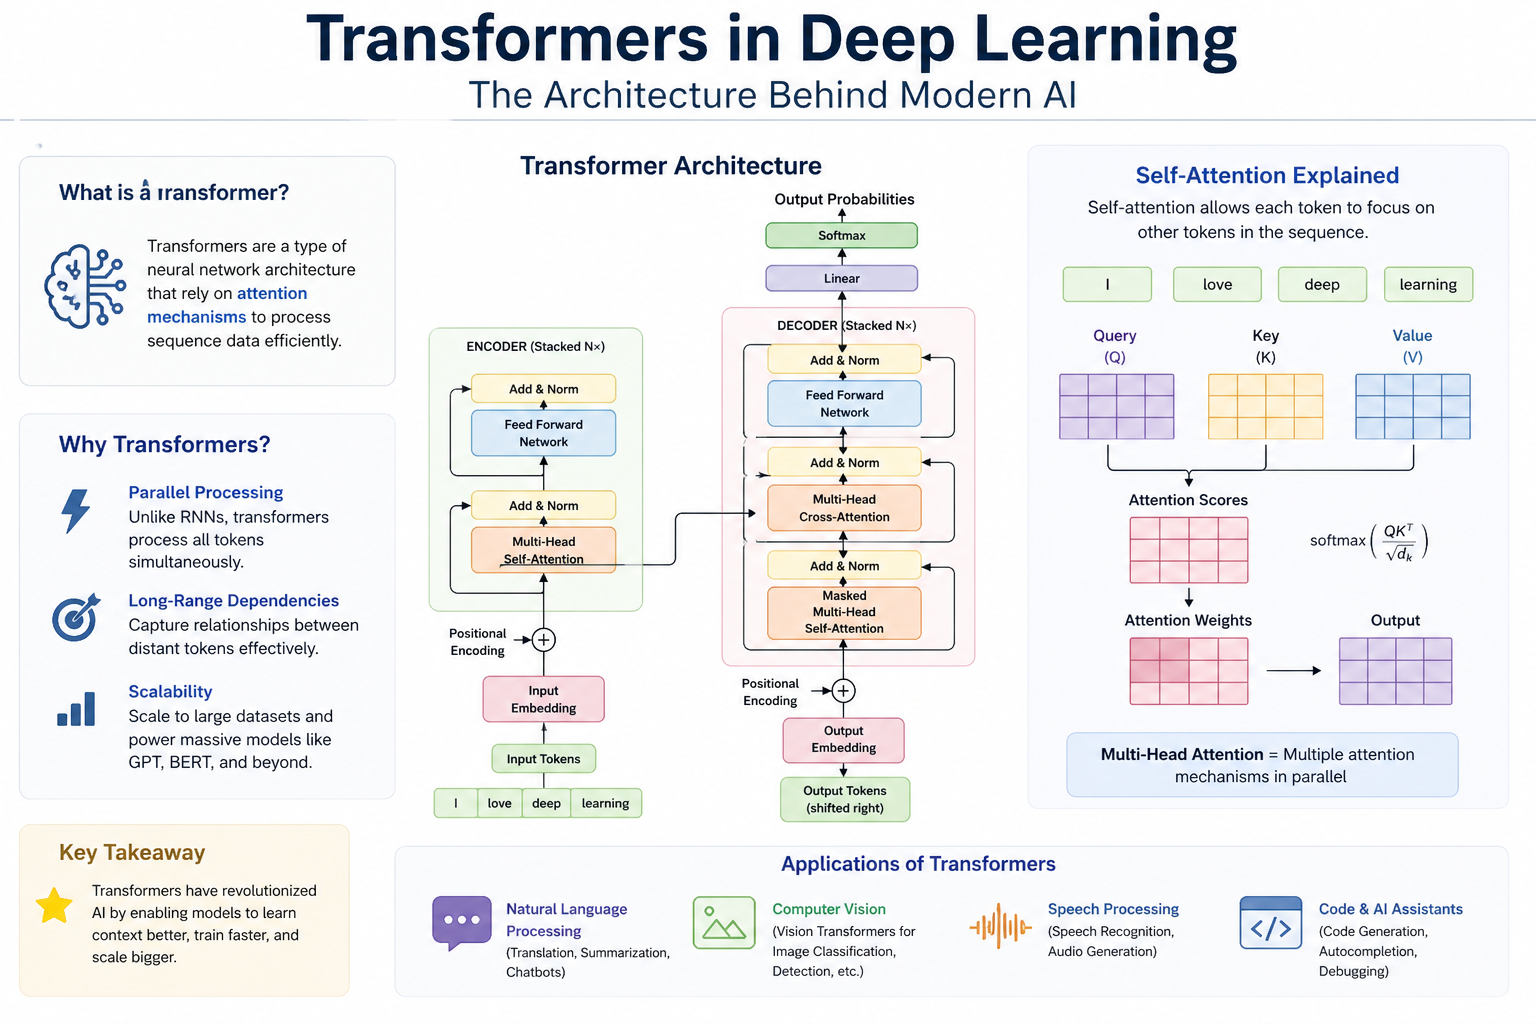


Transformers are deep learning architectures designed for sequence-to-sequence tasks like language translation and text generation. They uses a self-attention mechanism to effectively capture long-range dependencies within input sequences. In this article, we’ll implement a Transformer model from scratch using TensorFlow.

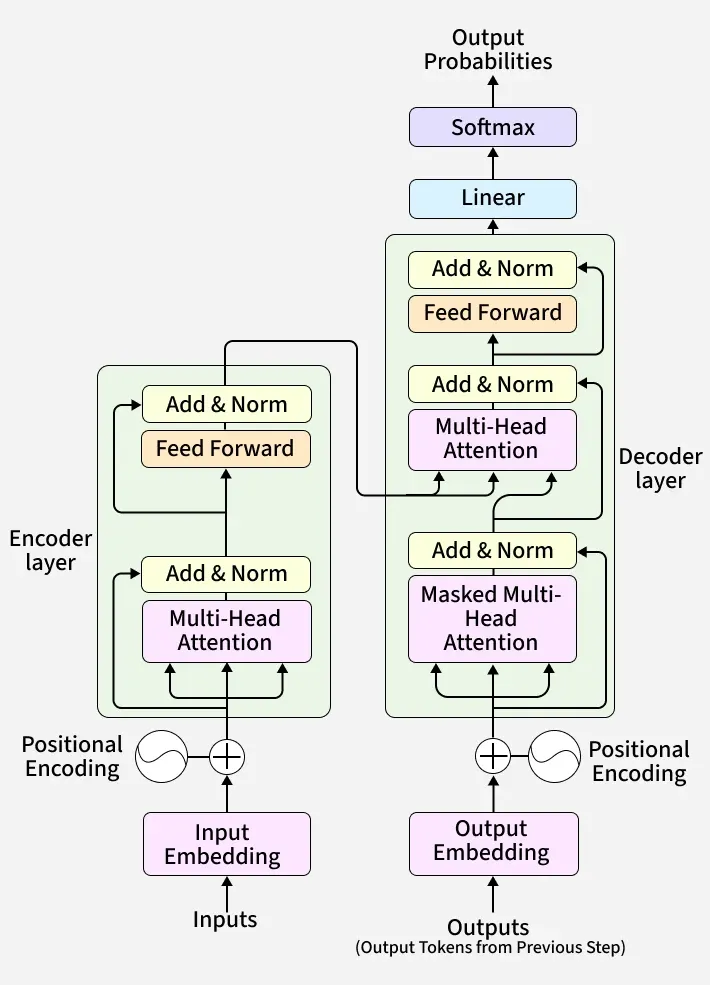

### 1. Importing Required Libraries



In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Embedding, Dropout, LayerNormalization
from tensorflow.keras.models import Model
import numpy as np

### 2. Defining Positional Encoding

Positional encoding is added to the input embeddings to provide information about the position of tokens in the sequence. Unlike RNNs and LSTMs, Transformers do not inherently capture the sequential nature of data so positional encodings are essential for injecting this information.

* **Positional Encoding:** This function creates a unique encoding for each position in the sequence, which is added to the token embeddings.
* **Sine and Cosine:** The positions are encoded using sine and cosine functions with different frequencies to distinguish the positions.

In [2]:
def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000, (2 * (np.arange(d_model) // 2)) / np.float32(d_model))
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

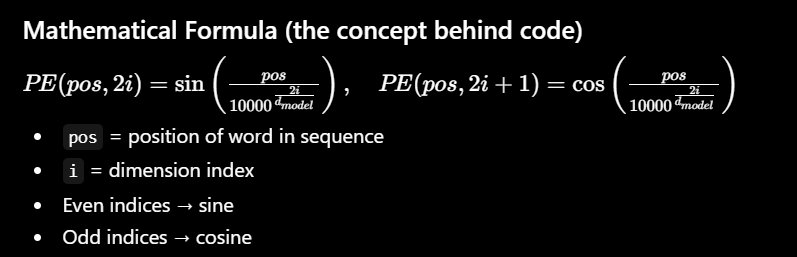

### 3. Defining Multi-Head Attention

The multi-head attention mechanism allows the model to focus on different parts of the input sequence simultaneously. It uses multiple attention heads to compute different representations of the input.

* **Multi-Head Attention:** This class performs multi-head attention by splitting the input into multiple heads which allows the model to focus on different parts of the sequence simultaneously.
* **d_model and num_heads:** d_model is the size of the embedding and num_heads refers to the number of attention heads.
* **Dense layers:** Linear transformations of the queries, keys and values are created through wq, wk and wv

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads
        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        self.dense = Dense(d_model)
    
    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])
    
    def scaled_dot_product_attention(self, q, k, v, mask):
        matul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matul_qk / tf.math.sqrt(dk)

        if mask is not None:
            scaled_attention_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights
    
    def call(self, v, k, q, mask):
        batch_size = tf.shape(q)[0]
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        
        attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        attention = tf.reshape(attention, (batch_size, -1, self.d_model))
        output = self.dense(attention)
        return output

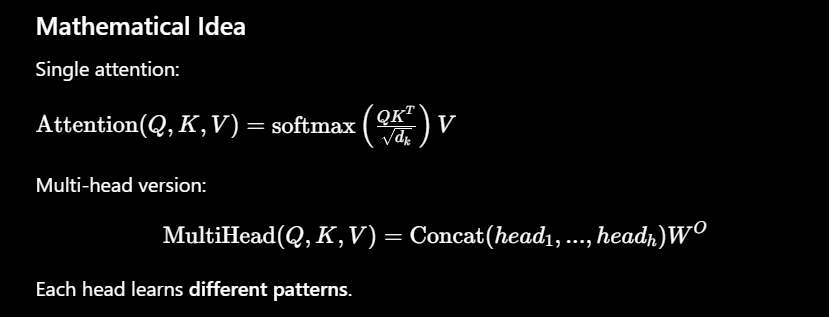

* **split_heads:** Splits the input tensor into multiple heads. The resulting tensor will have shape (batch_size, num_heads, seq_len, depth).

* **call:** This method performs the actual attention operation. It first computes the queries, keys and values by applying the corresponding Dense layers, splits them into heads and then calculates the attention using the scaled_dot_product_attention function.
* **scaled_dot_product_attention:** Computes attention using the scaled dot-product formula.

### 4. Defining Scaled Dot-Product Attention

Scaled Dot Product Attention is the core attention mechanism used by the multi-head attention component to compute attention scores.

* **Scaled Dot-Product Attention:** Computes the dot product between queries and keys, scales the result, applies a mask (if needed) and then calculates the weighted sum of values based on the attention weights.

### 5. Defining Feed Forward Network

The position-wise feed-forward network is used to process each position independently:

* **PositionwiseFeedforward:** This class applies two dense layers to each position independently. The first layer transforms the input to a higher dimension and the second one reduces it back to the original d_model size.
* **call:** Applies the feed-forward layers sequentially to the input.

In [7]:
class PositionwiseFeedforward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff):
        super(PositionwiseFeedforward, self).__init__()
        self.d_model = d_model
        self.dff = dff
        self.dense1 = Dense(dff, activation='relu')
        self.dense2 = Dense(d_model)

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return x

### 6. Defining Transformer Block

A transformer block combines multi-head attention and feed-forward networks with layer normalization and dropout.

In [8]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedforward(d_model, dff)
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)  
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, x, mask, training):
        attn_output = self.att(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

### 7. Defining Encoder

The encoder consists of a stack of encoder layers. It converts the input sequence into a set of embeddings enriched with positional information.

* **Encoder:** The encoder consists of an embedding layer, positional encoding, dropout and multiple transformer blocks. It processes the input sequence and generates a sequence representation.
* **call:** The input sequence is passed through the embedding layer, positional encoding is added and then it goes through the transformer blocks sequentially.

In [9]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.embedding = Embedding(input_vocab_size, d_model)
        self.pos_encoding = positional_encoding(
            maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)
        self.enc_layers = [TransformerBlock(
            d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]

    def call(self, x, training, mask):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x)
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)
        return x

### 8. Defining Decoder
    
The decoder generates the output sequence from the encoded representation using mechanisms to attend to both the encoder output and previously generated tokens.

* **call:** The input sequence is passed through embedding and positional encoding and then through the decoder transformer blocks.

In [10]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        self.embedding = Embedding(target_vocab_size, d_model)
        self.pos_encoding = positional_encoding(
            maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)
        self.dec_layers = [TransformerBlock(
            d_model, num_heads, dff, dropout_rate) for _ in range(num_layers)]

    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        seq_len = tf.shape(x)[1]
        attention_weights = {}
        x = self.embedding(x)
        x += self.pos_encoding[:, :seq_len, :]
        x = self.dropout(x, training=training)
        for i in range(self.num_layers):
            x = self.dec_layers[i](x, training=training, mask=look_ahead_mask)
        return x, attention_weights

### 9. Defining Transformer Model

The final model combines the encoder and decoder and outputs the final predictions.

In [11]:
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Transformer, self).__init__()
        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, maximum_position_encoding, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, maximum_position_encoding, dropout_rate)
        self.final_layer = Dense(target_vocab_size)

    def call(self, inputs, training=False, look_ahead_mask=None, padding_mask=None):
        inp, tar = inputs
        enc_output = self.encoder(inp, training=training, mask=padding_mask)
        dec_output, _ = self.decoder(tar, enc_output, training=training,
                                     look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
        final_output = self.final_layer(dec_output)

        return final_output

### 10. Training and Testing the Model

* For each of the 64 sentences in the batch the model generates 50 tokens.
* For each token position in each sentence the model outputs a probability distribution over the 8000 possible target vocabulary tokens.
* To obtain the final translated sequence we would typically take the token with the highest probability at each position resulting in a translated sentence.

In [14]:
# Defining Custom Parameters.
num_layers = 4
d_model = 128
num_heads = 8
dff = 512
input_vocab_size = 8500
target_vocab_size = 8000
maximum_position_encoding = 10000
dropout_rate = 0.1

transformer = Transformer(
    num_layers,
    d_model,
    num_heads,
    dff,
    input_vocab_size,
    target_vocab_size,
    maximum_position_encoding,
    dropout_rate
)

inputs = tf.random.uniform((64, 50), dtype=tf.int64,
                           minval=0, maxval=input_vocab_size)
targets = tf.random.uniform(
    (64, 50), dtype=tf.int64, minval=0, maxval=target_vocab_size)

look_ahead_mask = None
padding_mask = None

output = transformer((inputs, targets), training=True,
                     look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
print(output.shape)

(64, 50, 8000)


## Complete Code Block

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Embedding, Dropout, LayerNormalization
from tensorflow.keras.models import Model
import numpy as np


def positional_encoding(position, d_model):
    angle_rads = np.arange(position)[:, np.newaxis] / np.power(
        10000, (2 * (np.arange(d_model) // 2)) / np.float32(d_model)
    )
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pos_encoding = angle_rads[np.newaxis, ...]
    return tf.cast(pos_encoding, dtype=tf.float32)


class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        self.dense = Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None:
            scaled_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        scaled_attention, attention_weights = self.scaled_dot_product_attention(
            q, k, v, mask)

        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(
            scaled_attention, (batch_size, -1, self.d_model))

        output = self.dense(concat_attention)

        return output


class PositionwiseFeedforward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff):
        super().__init__()
        self.dense1 = Dense(dff, activation='relu')
        self.dense2 = Dense(d_model)

    def call(self, x):
        x = self.dense1(x)
        return self.dense2(x)


class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionwiseFeedforward(d_model, dff)
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        attn_output = self.att(x, x, x, mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2


class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 maximum_position_encoding, dropout_rate=0.1):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = Embedding(input_vocab_size, d_model)
        self.pos_encoding = positional_encoding(
            maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)

        self.enc_layers = [TransformerBlock(d_model, num_heads, dff, dropout_rate)
                           for _ in range(num_layers)]

    def call(self, x, training=False, mask=None):
        seq_len = tf.shape(x)[1]

        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)

        return x


class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size,
                 maximum_position_encoding, dropout_rate=0.1):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = Embedding(target_vocab_size, d_model)
        self.pos_encoding = positional_encoding(
            maximum_position_encoding, d_model)
        self.dropout = Dropout(dropout_rate)

        self.dec_layers = [TransformerBlock(d_model, num_heads, dff, dropout_rate)
                           for _ in range(num_layers)]

    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        seq_len = tf.shape(x)[1]
        attention_weights = {}

        x = self.embedding(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.dec_layers[i](x, training=training, mask=look_ahead_mask)

        return x, attention_weights


class Transformer(Model):
    def __init__(self, num_layers, d_model, num_heads, dff,
                 input_vocab_size, target_vocab_size, maximum_position_encoding,
                 dropout_rate=0.1):
        super().__init__()

        self.encoder = Encoder(num_layers, d_model, num_heads, dff,
                               input_vocab_size, maximum_position_encoding, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff,
                               target_vocab_size, maximum_position_encoding, dropout_rate)
        self.final_layer = Dense(target_vocab_size)

    def call(self, inputs, training=False, look_ahead_mask=None, padding_mask=None):
        inp, tar = inputs

        enc_output = self.encoder(inp, training=training, mask=padding_mask)

        dec_output, _ = self.decoder(tar, enc_output, training=training,
                                     look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)

        final_output = self.final_layer(dec_output)

        return final_output


# Example hyperparameters
num_layers = 2
d_model = 128
num_heads = 8
dff = 512
input_vocab_size = 8500
target_vocab_size = 8000
maximum_position_encoding = 10000
dropout_rate = 0.1

transformer = Transformer(
    num_layers,
    d_model,
    num_heads,
    dff,
    input_vocab_size,
    target_vocab_size,
    maximum_position_encoding,
    dropout_rate
)

inputs = tf.random.uniform((64, 50), dtype=tf.int64,
                           minval=0, maxval=input_vocab_size)
targets = tf.random.uniform(
    (64, 50), dtype=tf.int64, minval=0, maxval=target_vocab_size)

look_ahead_mask = None
padding_mask = None

output = transformer((inputs, targets), training=True,
                     look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)

print(output.shape)

(64, 50, 8000)
